# Comparator for data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

In [2]:
en_before = pd.read_csv("./mistral7b/generated_before.csv")
en_after = pd.read_csv("./mistral7b/generated_stories.csv")

jp_before = pd.read_csv("./rinna-jp-model/generated_before.csv")
jp_after = pd.read_csv("./rinna-jp-model/generated_stories.csv")

print("EN before:", len(en_before))
print("EN after:", len(en_after))
print("JP before:", len(jp_before))
print("JP after:", len(jp_after))

EN before: 20
EN after: 20
JP before: 200
JP after: 80


## Baseline Metric 1: Story Length

In [3]:
def word_count(text):
    return len(str(text).split())

def char_count(text):
    return len(str(text))

for df in [en_before, en_after, jp_before, jp_after]:
    df["word_count"] = df["story"].apply(word_count)
    df["char_count"] = df["story"].apply(char_count)

In [4]:
summary = pd.DataFrame({
    "EN_before_words": [en_before["word_count"].mean()],
    "EN_after_words": [en_after["word_count"].mean()],
    "JP_before_chars": [jp_before["char_count"].mean()],
    "JP_after_chars": [jp_after["char_count"].mean()]
})

summary

,EN_before_words,EN_after_words,JP_before_chars,JP_after_chars
0,172.65,178.2,258.02,698.8


## Vocabulary Richness (English)

In [5]:
def type_token_ratio(texts):
    words = []
    for t in texts:
        words += re.findall(r"\b\w+\b", str(t).lower())
    return len(set(words)) / len(words)

print("EN before TTR:", type_token_ratio(en_before["story"]))
print("EN after TTR:", type_token_ratio(en_after["story"]))

EN before TTR: 0.2665324899367453
EN after TTR: 0.27649643053267436


In [6]:
def char_type_token_ratio(texts):
    all_chars = []
    for t in texts:
        all_chars += list(str(t))
    return len(set(all_chars)) / len(all_chars)

print("JP before char-TTR:", char_type_token_ratio(jp_before["story"]))
print("JP after  char-TTR:", char_type_token_ratio(jp_after["story"]))

JP before char-TTR: 0.013681109991473529
JP after  char-TTR: 0.019909129937034916


## Repetition Score

In [7]:
def repetition_score(text):
    words = text.split()
    counts = Counter(words)
    repeated = sum(v for v in counts.values() if v > 1)
    return repeated / len(words) if words else 0

en_before["repetition"] = en_before["story"].apply(repetition_score)
en_after["repetition"] = en_after["story"].apply(repetition_score)

print("EN repetition before:", en_before["repetition"].mean())
print("EN repetition after:", en_after["repetition"].mean())

EN repetition before: 0.3120346684580477
EN repetition after: 0.3477582639467217


## Entropy

In [8]:
import math
def entropy(texts):
    tokens = []
    for t in texts:
        #character-level entropy
        tokens += list(str(t))

    counts = Counter(tokens)
    total = sum(counts.values())

    return -sum((c/total) * math.log2(c/total) for c in counts.values())

print("EN entropy:", entropy(en_after["story"]))
print("JP entropy:", entropy(jp_after["story"]))

EN entropy: 4.4276677591816425
JP entropy: 7.658494659915968


# Sentences

In [9]:
def avg_sentence_length(texts, split_token):
    lengths = []
    for t in texts:
        sentences = str(t).split(split_token)
        sentences = [s for s in sentences if len(s.strip()) > 0]
        lengths += [len(s) for s in sentences]
    return np.mean(lengths)

print("EN avg sentence length:", avg_sentence_length(en_after["story"], "."))
print("JP avg sentence length:", avg_sentence_length(jp_after["story"], "。"))

EN avg sentence length: 120.8232044198895
JP avg sentence length: 52.421203438395416


### Narrative Structure Signal (Kishōtenketsu Hypothesis)

In [10]:
'''
Kishōtenketsu structure:
- Introduction
- Development
- Twist
- Conclusion
'''

from textblob import TextBlob

def sentiment_progression(text):
    sentences = text.split(".")
    scores = [TextBlob(s).sentiment.polarity for s in sentences if s.strip()]
    return scores

sample_en = en_after["story"].iloc[0]
print(sentiment_progression(sample_en))

[-0.0375, 0.175, -0.2, 0.25, 0.25, 0.0, 0.25, 0.03333333333333333, -0.25]


## High-frequency word difference

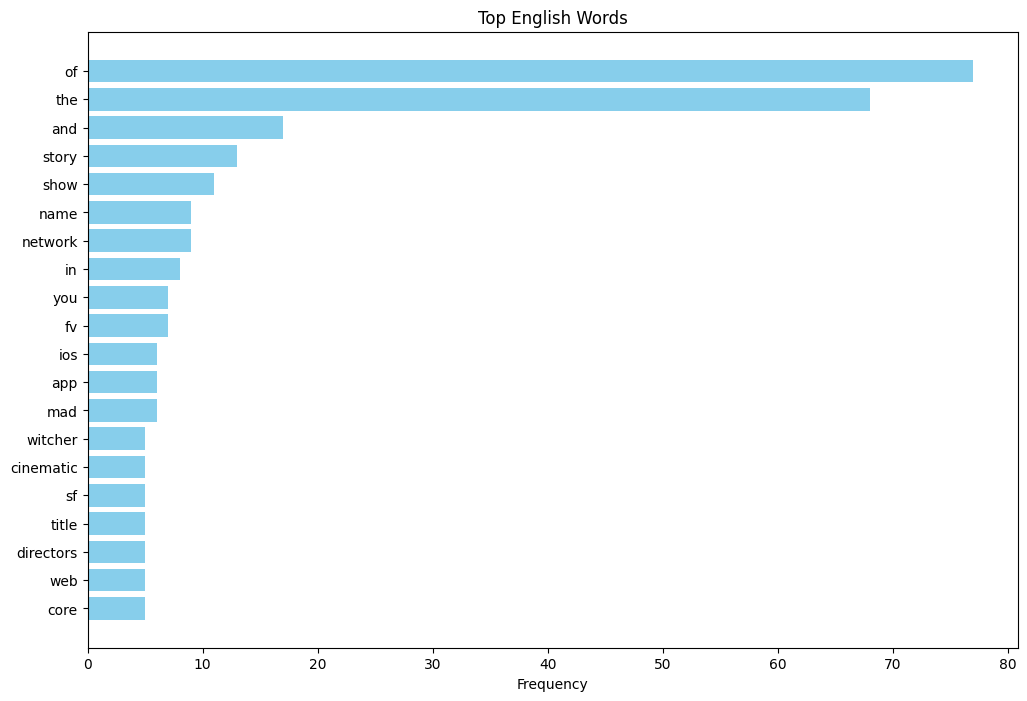

Top English Words: [('of', 77), ('the', 68), ('and', 17), ('story', 13), ('show', 11), ('name', 9), ('network', 9), ('in', 8), ('you', 7), ('fv', 7), ('ios', 6), ('app', 6), ('mad', 6), ('witcher', 5), ('cinematic', 5), ('sf', 5), ('title', 5), ('directors', 5), ('web', 5), ('core', 5)]


In [11]:
def get_top_english_words(texts, n=20):
    all_words = []
    
    blocklist = {
        #links
        'https', 'http', 'www', 'com', 'net', 'org', 
        #genres
        'fantasy', 'romance', 'comedy', 'shoujo', 'shounen', 
        'slice', 'life', 'action', 'adventure', 'drama', 'sci', 'fi', 'shojo',
        #junk
        'nl', 'n', 'br', 'categoricaltext'
    }

    for t in texts:
        clean_text = str(t).lower()
        
        #Extract words
        words = re.findall(r'[a-zA-Z]+', clean_text)
        
        #Filter
        filtered_words = [w for w in words if w not in blocklist and len(w) > 1]
        
        all_words.extend(filtered_words)
    
    return Counter(all_words).most_common(n)

top_data = get_top_english_words(jp_after["story"], n=20) 

words = [item[0] for item in top_data]
counts = [item[1] for item in top_data]

plt.figure(figsize=(12, 8))
plt.barh(words, counts, color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top English Words")
plt.xlabel("Frequency")
plt.show()

print("Top English Words:", top_data)

In [12]:
def top_chars(texts, n=20):
    chars = []
    for t in texts:
        chars += list(str(t))
    return Counter(chars).most_common(n)

print("Top JP characters:", top_chars(jp_after["story"]))

Top JP characters: [('の', 1764), ('、', 1517), (' ', 1279), ('い', 1274), ('ー', 1155), ('す', 1107), ('し', 1072), ('ま', 1069), ('に', 1029), ('。', 1019), ('を', 963), ('た', 939), ('て', 918), ('は', 907), ('で', 887), ('-', 859), ('る', 814), ('が', 775), ('と', 748), ('e', 734)]


## Part-of-Speech (POS) Distribution

In [13]:
# setup
#!python -m spacy download en_core_web_sm
#!python -m spacy download ja_core_news_sm
import spacy

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


In [14]:
def get_pos_distribution(texts, nlp_model):
    # ADP for adpositions/particles
    pos_counts = {'PRON': 0, 'NOUN': 0, 'VERB': 0, 'ADP': 0}
    total_tokens = 0
    
    # process text in batches
    for doc in nlp_model.pipe(texts.astype(str), batch_size=20):
        for token in doc:
            if token.pos_ in pos_counts:
                pos_counts[token.pos_] += 1
            total_tokens += 1
            
    # normalize counts
    if total_tokens > 0:
        for k in pos_counts:
            pos_counts[k] = (pos_counts[k] / total_tokens) * 100
    return pos_counts

English pronoun to noun ratio: 0.2704
Japanese pronoun to noun ratio: 0.1252


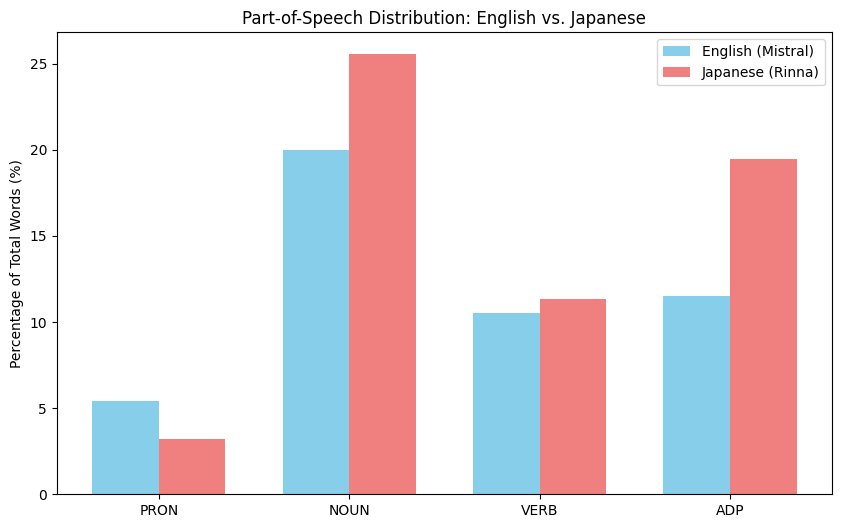

In [15]:
# load spacy for jp and en
nlp_en = spacy.load("en_core_web_sm")
nlp_jp = spacy.load("ja_core_news_sm")

# get jp and en pos distributions
pos_en = get_pos_distribution(en_after["story"], nlp_en)
pos_jp = get_pos_distribution(jp_after["story"], nlp_jp)

# calculate pronoun to noun ratios
en_pron_noun_ratio = pos_en['PRON'] / pos_en['NOUN'] if pos_en['NOUN'] > 0 else 0
jp_pron_noun_ratio = pos_jp['PRON'] / pos_jp['NOUN'] if pos_jp['NOUN'] > 0 else 0

print(f"English pronoun to noun ratio: {en_pron_noun_ratio:.4f}")
print(f"Japanese pronoun to noun ratio: {jp_pron_noun_ratio:.4f}")

# plot data
labels = list(pos_en.keys())
en_values = list(pos_en.values())
jp_values = list(pos_jp.values())
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rectangles1 = ax.bar(x - width/2, en_values, width, label='English (Mistral)', color='skyblue')
rectangles2 = ax.bar(x + width/2, jp_values, width, label='Japanese (Rinna)', color='lightcoral')

# show plot 
ax.set_ylabel('Percentage of Total Words (%)')
ax.set_title('Part-of-Speech Distribution: English vs. Japanese')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

## Cross-Lingual Sentiment Variance

In [16]:
# imports
from transformers import pipeline
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

/home/adrian/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
# calculates sentiment scores in batches
def get_sentiment_variance(texts):
    # filter empty strings
    valid_texts = [str(t) for t in texts if str(t).strip()]
    
    # use trunctation to handle 512 token limit
    results = sentiment_pipeline(valid_texts, batch_size=16, truncation=True, max_length=512)
    
    # get integer score from label
    scores = [int(res['label'].split()[0]) for res in results]

    # calculate and return results
    variance = np.var(scores)
    std_dev = np.std(scores)
    return variance, std_dev, scores

Loading weights: 100%|████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 5052.08it/s]


English sentiment variance: 0.0000
Engligh standard deviation: 0.0000
Japanese sentiment variance: 0.0798
Japanese standard Deviation: 0.2826


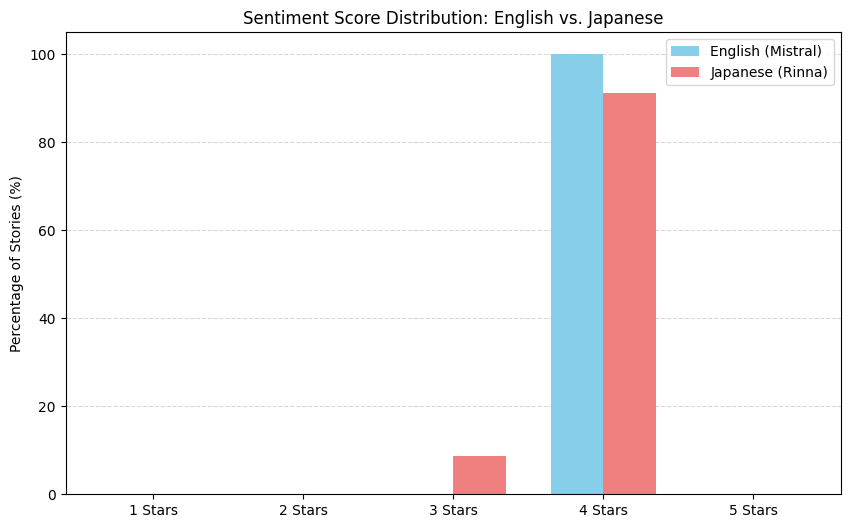

In [20]:
# load model with truncation for long texts
sentiment_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# get sentiment analysis
en_var, en_std, en_scores = get_sentiment_variance(en_after["story"])
jp_var, jp_std, jp_scores = get_sentiment_variance(jp_after["story"])

print(f"English sentiment variance: {en_var:.4f}")
print(f"Engligh standard deviation: {en_std:.4f}")
print(f"Japanese sentiment variance: {jp_var:.4f}")
print(f"Japanese standard Deviation: {jp_std:.4f}")

# gives labels scores and count them
en_counts = Counter(en_scores)
jp_counts = Counter(jp_scores)

# use percentage to account for the difference in the amount of stories
# plot data
labels = [1, 2, 3, 4, 5]
en_pct = [en_counts.get(i, 0) / len(en_scores) * 100 for i in labels]
jp_pct = [jp_counts.get(i, 0) / len(jp_scores) * 100 for i in labels]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, en_pct, width, label='English (Mistral)', color='skyblue')
rects2 = ax.bar(x + width/2, jp_pct, width, label='Japanese (Rinna)', color='lightcoral')

# show plot
ax.set_ylabel('Percentage of Stories (%)')
ax.set_title('Sentiment Score Distribution: English vs. Japanese')
ax.set_xticks(x)
ax.set_xticklabels([f"{i} Stars" for i in labels])
ax.legend()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.3)
plt.show()